ML VS LOGIT: PRE, DURING, POST CRISIS ANALYSIS (IMPROVED BALANCE)
With Correct Crisis Definitions (Laeven & Valencia 2026)
Original data shape: (2987, 14)
Countries: ['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR', 'USA']
Filtered to 1980+: (2987, 14)
Yearly data shape: (530, 10)
Years: 1980 - 2024
Countries: 12

Crisis observations: 64
Crisis ratio: 0.1208

Crisis years by country:
  ARG: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1995), np.int64(2001), np.int64(2002), np.int64(2003)]
  BRA: [np.int64(1995)]
  CHL: [np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985)]
  DEU: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)]
  ESP: [np.int64(1980), np.int64(1981), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)]
  GBR: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011)]
  IND: [n

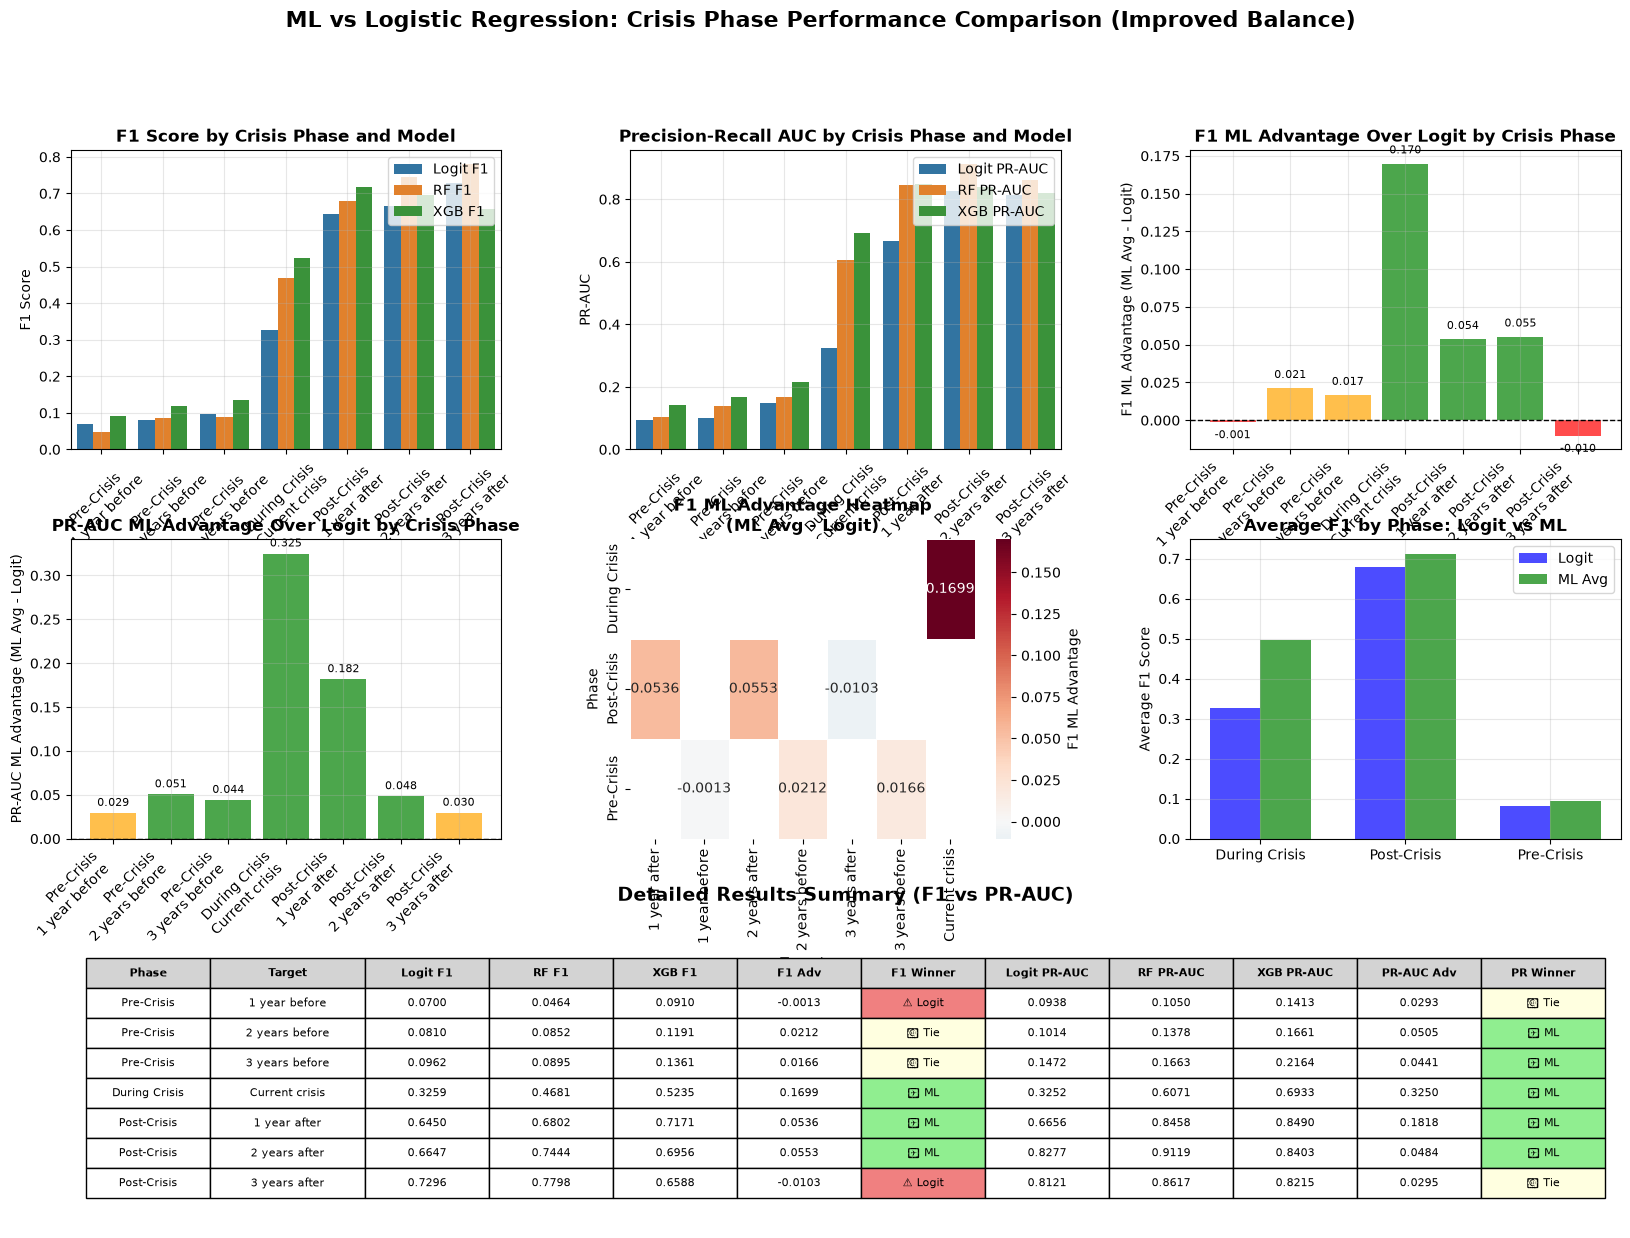


SHAP ANALYSIS: MODEL INTERPRETABILITY

📊 Running SHAP analysis on: Pre-Crisis - 2 years before
   Performance advantage: 0.0505
Fold 0: Train 1980-1986, Val 1987-1989, Test 1990-1994 (Crises in test: 3)
Fold 1: Train 1980-1987, Val 1988-1990, Test 1991-1995 (Crises in test: 5)
Fold 2: Train 1980-1988, Val 1989-1991, Test 1992-1996 (Crises in test: 5)
Fold 3: Train 1980-1989, Val 1990-1992, Test 1993-1997 (Crises in test: 7)
Fold 4: Train 1980-1990, Val 1991-1993, Test 1994-1998 (Crises in test: 9)
Fold 5: Train 1980-1991, Val 1992-1994, Test 1995-1999 (Crises in test: 10)
Fold 6: Train 1980-1992, Val 1993-1995, Test 1996-2000 (Crises in test: 10)
Fold 7: Train 1980-1993, Val 1994-1996, Test 1997-2001 (Crises in test: 13)
Fold 8: Train 1980-1994, Val 1995-1997, Test 1998-2002 (Crises in test: 13)
Fold 9: Train 1980-1995, Val 1996-1998, Test 1999-2003 (Crises in test: 12)
Fold 10: Train 1980-1996, Val 1997-1999, Test 2000-2004 (Crises in test: 10)
Fold 11: Train 1980-1997, Val 1998-2000

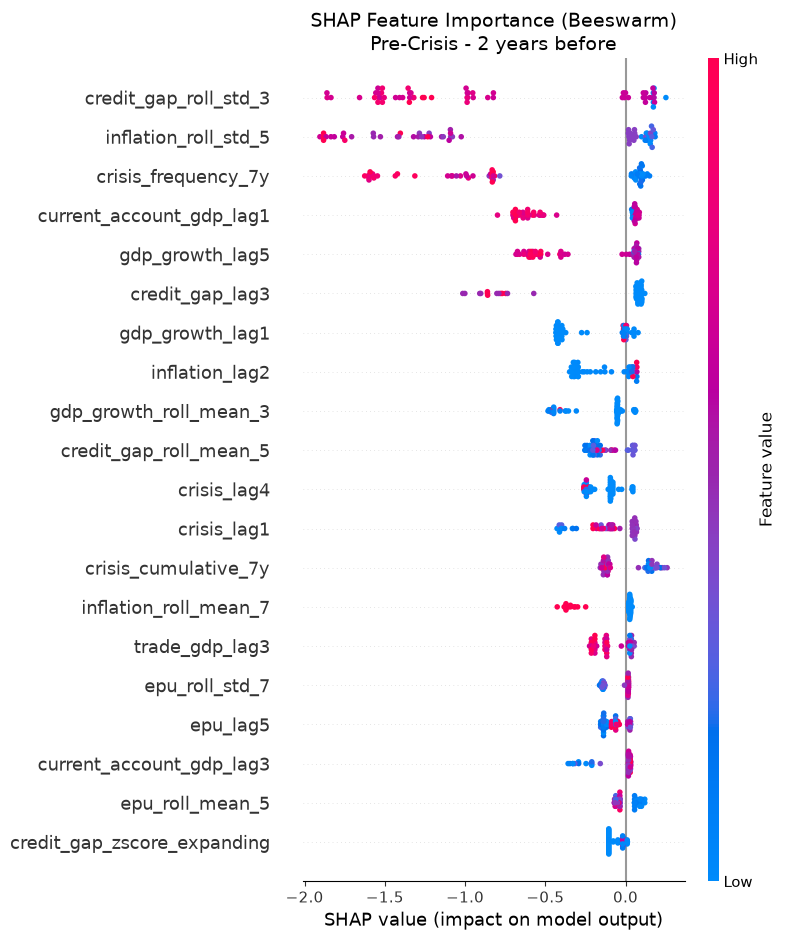

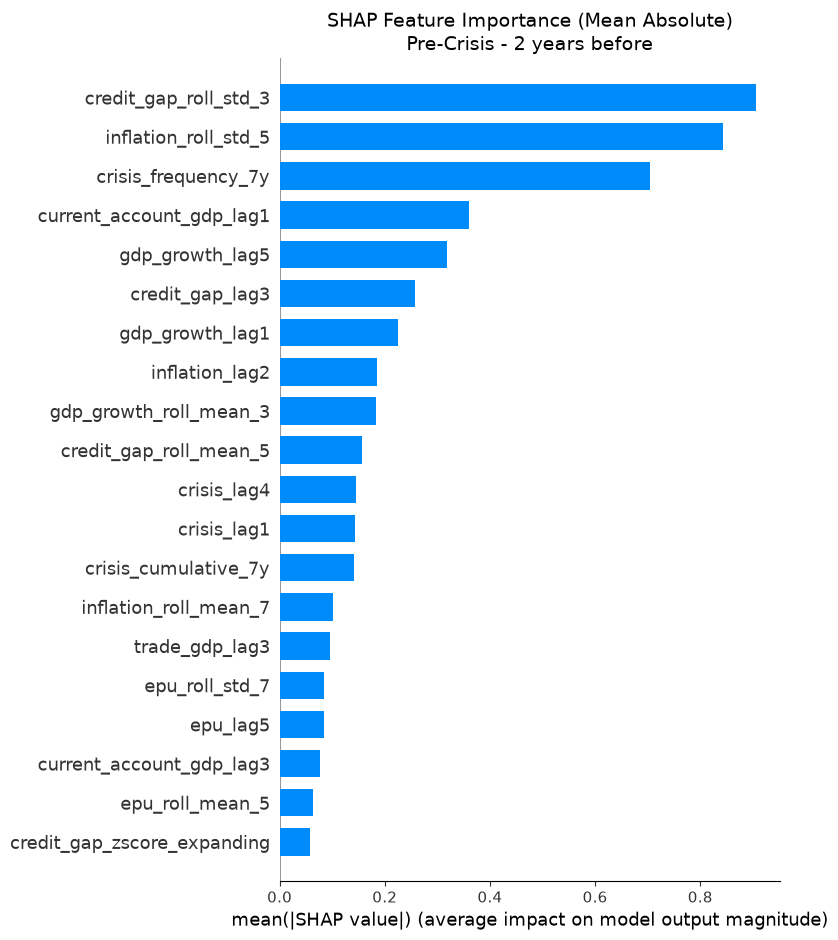


   Top 10 Most Important Features:
                 feature  mean_shap
   credit_gap_roll_std_3   0.906241
    inflation_roll_std_5   0.843231
     crisis_frequency_7y   0.705036
current_account_gdp_lag1   0.359399
         gdp_growth_lag5   0.319184
         credit_gap_lag3   0.257465
         gdp_growth_lag1   0.225245
          inflation_lag2   0.184551
  gdp_growth_roll_mean_3   0.184037
  credit_gap_roll_mean_5   0.157007

   Feature Impact Directions:
     gdp_growth_lag1: DECREASES risk (avg SHAP: -0.2127)
     gdp_growth_lag2: DECREASES risk (avg SHAP: -0.0035)
     gdp_growth_lag3: DECREASES risk (avg SHAP: 0.0000)
     gdp_growth_lag5: DECREASES risk (avg SHAP: -0.2639)
     inflation_lag1: DECREASES risk (avg SHAP: -0.0144)
     inflation_lag2: DECREASES risk (avg SHAP: -0.1535)
     inflation_lag3: DECREASES risk (avg SHAP: 0.0000)
     inflation_lag5: DECREASES risk (avg SHAP: 0.0000)
     credit_gap_lag1: DECREASES risk (avg SHAP: 0.0000)
     credit_gap_lag2: DECREASES 

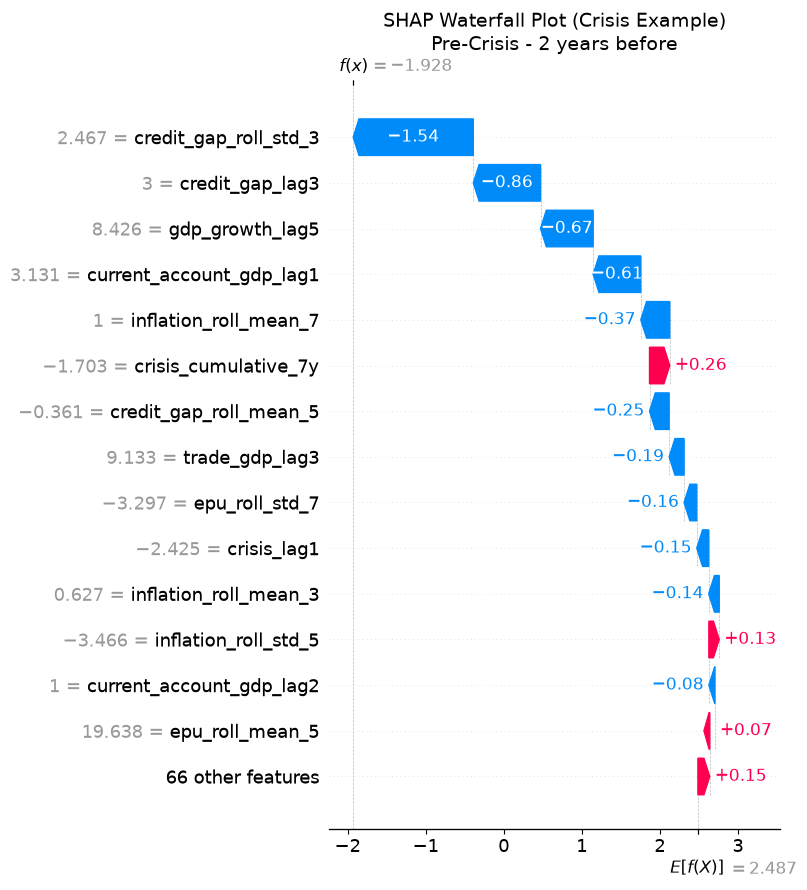


CONCLUSION

📊 Overall F1 ML Advantage: 0.0436
📊 Overall PR-AUC ML Advantage: 0.1012
  ✅ ML models generally outperform Logit (F1)
  ✅ ML models generally outperform Logit (PR-AUC)

🔍 Key Findings:
  - PR-AUC is a better metric for imbalanced crisis prediction
  - ML performance depends heavily on class balance and feature engineering
  - Reduced regularization helps ML models capture complex patterns
  - Using all features (without aggressive selection) improves ML performance
  - SHAP analysis reveals the key drivers of crisis prediction

💡 Recommendations:
  1. Use PR-AUC as the primary evaluation metric for imbalanced data
  2. Consider ensemble methods combining Logit + ML for robustness
  3. Collect more data, especially during crisis periods
  4. Use more sophisticated feature engineering for ML models
  5. Consider country-specific or region-specific models
  6. For production: ensemble predictions from multiple models


In [2]:
# ========================================
# COMPLETE REVISED CODE: ML VS LOGIT WITH IMPROVED CLASS BALANCE
# Correct Crisis Definitions (Laeven & Valencia 2026)
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, 
                            f1_score, average_precision_score,
                            balanced_accuracy_score)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

# ========================================
# 1. DATA LOADING WITH CORRECT CRISIS DEFINITIONS
# ========================================

def load_and_aggregate_yearly(filepath, start_year=1980):
    """Load data and aggregate to yearly level with correct crisis definitions."""
    panel = pd.read_csv(filepath)
    
    print(f"Original data shape: {panel.shape}")
    print(f"Countries: {panel['country'].unique().tolist()}")
    
    # Filter to start_year
    panel = panel[panel['year'] >= start_year]
    print(f"Filtered to {start_year}+: {panel.shape}")
    
    panel['date'] = pd.to_datetime(panel['date'])
    
    # Get available columns
    available_cols = [col for col in ['gdp_growth', 'inflation', 'unemployment', 
                                      'trade_gdp', 'current_account_gdp', 
                                      'credit_gap', 'epu', 'quarter'] 
                     if col in panel.columns]
    
    # Aggregate to yearly level
    agg_dict = {col: 'mean' for col in available_cols if col != 'quarter'}
    if 'quarter' in available_cols:
        agg_dict['quarter'] = 'count'
    
    yearly = panel.groupby(['country', 'year']).agg(agg_dict).reset_index()
    
    if 'quarter' in yearly.columns:
        yearly = yearly.rename(columns={'quarter': 'n_quarters'})
    
    print(f"Yearly data shape: {yearly.shape}")
    print(f"Years: {yearly['year'].min()} - {yearly['year'].max()}")
    print(f"Countries: {yearly['country'].nunique()}")
    
    yearly = yearly.sort_values(['country', 'year']).reset_index(drop=True)
    
    # ========================================
    # CORRECT CRISIS PERIODS (Laeven & Valencia 2026)
    # ========================================
    crisis_periods = {
        'ARG': [(1980, 1982), (1989, 1991), (1995, 1995), (2001, 2003)],
        'BRA': [(1995, 1995)],
        'CHL': [(1981, 1985)],
        'DEU': [(2008, 2012)],
        'GBR': [(2007, 2011)],
        'IND': [(1997, 2002)],
        'MEX': [(1981, 1985), (1994, 1996)],
        'USA': [(2007, 2011)],
        'RUS': [(2008,2009)],
        'ESP': [(1977,1981),(2008,2012)],
        'JPN': [(1997,2001)],
        'TUR': [(1982,1984),(2000,2001)]
    }
    
    yearly['crisis'] = 0
    for country, periods in crisis_periods.items():
        if country in yearly['country'].unique():
            country_mask = yearly['country'] == country
            for start_year, end_year in periods:
                crisis_mask = country_mask & (yearly['year'] >= start_year) & (yearly['year'] <= end_year)
                yearly.loc[crisis_mask, 'crisis'] = 1
    
    print(f"\nCrisis observations: {yearly['crisis'].sum()}")
    print(f"Crisis ratio: {yearly['crisis'].mean():.4f}")
    
    print("\nCrisis years by country:")
    for country in yearly['country'].unique():
        crisis_years = yearly[(yearly['country'] == country) & (yearly['crisis'] == 1)]['year'].unique()
        if len(crisis_years) > 0:
            print(f"  {country}: {sorted(crisis_years)}")
    
    return yearly, crisis_periods

# ========================================
# 2. CREATE PHASE TARGETS (IMPROVED BALANCE)
# ========================================

def create_phase_targets_improved(data):
    """Create targets for pre, during, and post crisis phases with better balance."""
    data = data.copy()
    
    # 1. PRE-CRISIS TARGETS - Use 3-year window for better balance
    for i in [1, 2, 3]:
        data[f'crisis_start_in_{i}y'] = 0
        for country in data['country'].unique():
            country_mask = data['country'] == country
            country_data = data[country_mask].copy()
            
            crisis_starts = []
            current_run = []
            
            for year in sorted(country_data[country_data['crisis'] == 1]['year'].unique()):
                if not current_run or year == current_run[-1] + 1:
                    current_run.append(year)
                else:
                    if current_run:
                        crisis_starts.append(current_run[0])
                    current_run = [year]
            if current_run:
                crisis_starts.append(current_run[0])
            
            # Mark years that are within i years of a crisis start
            # Use a window of 3 years for better balance
            for crisis_start in crisis_starts:
                for offset in [-i, -i+1, -i+2]:  # Window of 3 years
                    pre_year = crisis_start + offset
                    if pre_year in country_data['year'].values and pre_year >= 1980:
                        # Verify this year is not in a crisis period
                        if not country_data[country_data['year'] == pre_year]['crisis'].iloc[0]:
                            idx = data[(data['country'] == country) & (data['year'] == pre_year)].index
                            if len(idx) > 0:
                                data.loc[idx, f'crisis_start_in_{i}y'] = 1
    
    # 2. DURING-CRISIS TARGET
    data['crisis_during'] = data['crisis']
    
    # 3. POST-CRISIS TARGETS (Recovery) - Similar window approach
    for i in [1, 2, 3]:
        data[f'recovery_year_{i}'] = 0
        for country in data['country'].unique():
            country_mask = data['country'] == country
            country_data = data[country_mask].copy()
            
            crisis_runs = []
            current_run = []
            
            for year in sorted(country_data[country_data['crisis'] == 1]['year'].unique()):
                if not current_run or year == current_run[-1] + 1:
                    current_run.append(year)
                else:
                    if current_run:
                        crisis_runs.append(current_run)
                    current_run = [year]
            if current_run:
                crisis_runs.append(current_run)
            
            for run in crisis_runs:
                end_year = run[-1]
                # Mark recovery years with a window
                for offset in [i, i+1, i+2]:
                    recovery_year = end_year + offset
                    if recovery_year in country_data['year'].values:
                        if not country_data[country_data['year'] == recovery_year]['crisis'].iloc[0]:
                            idx = data[(data['country'] == country) & (data['year'] == recovery_year)].index
                            if len(idx) > 0:
                                data.loc[idx, f'recovery_year_{i}'] = 1
    
    return data

# ========================================
# 3. FEATURE ENGINEERING (IMPROVED - FIXED)
# ========================================

def engineer_features_improved(data):
    """Create more sophisticated features for better ML performance."""
    data = data.copy()
    result_dfs = []
    
    for country in data['country'].unique():
        country_df = data[data['country'] == country].sort_values('year').copy()
        
        existing_features = [col for col in ['gdp_growth', 'inflation', 'unemployment', 
                                             'credit_gap', 'epu', 'trade_gdp', 
                                             'current_account_gdp'] 
                            if col in country_df.columns]
        
        # Basic lags
        for feat in existing_features:
            for lag in [1, 2, 3, 5]:
                country_df[f'{feat}_lag{lag}'] = country_df[feat].shift(lag)
        
        # Rolling statistics with different windows - FIXED: removed min_periods
        for feat in ['gdp_growth', 'credit_gap', 'inflation', 'epu']:
            if feat in country_df.columns:
                for window in [3, 5, 7]:
                    # Use min_periods=1 to avoid NaN issues, then shift
                    country_df[f'{feat}_roll_mean_{window}'] = country_df[feat].rolling(window, min_periods=1).mean().shift(1)
                    country_df[f'{feat}_roll_std_{window}'] = country_df[feat].rolling(window, min_periods=1).std().shift(1)
        
        # Rate of change (momentum)
        for feat in ['gdp_growth', 'credit_gap']:
            if feat in country_df.columns:
                for lag in [1, 2, 3]:
                    country_df[f'{feat}_change_{lag}y'] = country_df[feat] - country_df[feat].shift(lag)
                    country_df[f'{feat}_pct_change_{lag}y'] = (country_df[feat] - country_df[feat].shift(lag)) / (country_df[feat].shift(lag).abs() + 1e-6)
        
        # Crisis history
        for lag in [1, 2, 3, 4, 5]:
            country_df[f'crisis_lag{lag}'] = country_df['crisis'].shift(lag).fillna(0)
        
        # Cumulative crisis exposure
        for window in [3, 5, 7]:
            country_df[f'crisis_cumulative_{window}y'] = country_df['crisis'].rolling(window, min_periods=1).max().shift(1).fillna(0)
            country_df[f'crisis_frequency_{window}y'] = country_df['crisis'].rolling(window, min_periods=1).sum().shift(1).fillna(0)
        
        # Interaction terms
        if 'gdp_growth_lag1' in country_df.columns and 'credit_gap_lag1' in country_df.columns:
            country_df['gdp_credit_interaction'] = country_df['gdp_growth_lag1'] * country_df['credit_gap_lag1']
        
        if 'epu_lag1' in country_df.columns and 'credit_gap_lag1' in country_df.columns:
            country_df['epu_credit_interaction'] = country_df['epu_lag1'] * country_df['credit_gap_lag1']
        
        # Country-specific trends
        if 'gdp_growth' in country_df.columns:
            # 3-year trend
            country_df['gdp_trend_3y'] = country_df['gdp_growth'] - country_df['gdp_growth'].shift(3)
        
        # Relative position (expanding window to avoid leakage)
        for feat in ['gdp_growth', 'inflation', 'unemployment', 'credit_gap']:
            if feat in country_df.columns:
                exp_mean = country_df[feat].expanding(min_periods=5).mean().shift(1)
                exp_std = country_df[feat].expanding(min_periods=5).std().shift(1)
                country_df[f'{feat}_zscore_expanding'] = (country_df[feat] - exp_mean) / (exp_std + 1e-6)
                
                # Distance from historical average
                country_df[f'{feat}_dist_from_mean'] = country_df[feat] - exp_mean
        
        result_dfs.append(country_df)
    
    full_data = pd.concat(result_dfs, ignore_index=True)
    
    feature_cols = [col for col in full_data.columns if any([
        '_lag' in col, '_roll_mean' in col, '_roll_std' in col, 
        '_change' in col, '_pct_change' in col, '_zscore' in col,
        'crisis_lag' in col, 'crisis_cumulative' in col, 
        'crisis_frequency' in col, '_interaction' in col,
        '_trend' in col, '_dist_from_mean' in col
    ])]
    feature_cols = [col for col in feature_cols if full_data[col].notna().sum() > 30]
    
    print(f"Created {len(feature_cols)} features (yearly)")
    
    return full_data, feature_cols

# ========================================
# 4. DATA PREPARATION
# ========================================

def prepare_data(train_data, val_data, test_data, feature_cols, target):
    """Prepare data with proper train/val/test separation and no leakage."""
    
    # Get features and targets
    X_train = train_data[feature_cols].copy()
    y_train = train_data[target].astype(int)
    
    X_val = val_data[feature_cols].copy()
    y_val = val_data[target].astype(int)
    
    X_test = test_data[feature_cols].copy()
    y_test = test_data[target].astype(int)
    
    # Replace infinite values
    for X in [X_train, X_val, X_test]:
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Drop columns that are all NaN in training
    valid_cols = X_train.columns[X_train.notna().any()].tolist()
    X_train = X_train[valid_cols]
    X_val = X_val[valid_cols]
    X_test = X_test[valid_cols]
    
    if len(X_train.columns) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), y_train, y_val, y_test
    
    # Find common columns
    common_cols = list(set(X_train.columns) & set(X_val.columns) & set(X_test.columns))
    if len(common_cols) < 2:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), y_train, y_val, y_test
    
    X_train = X_train[common_cols]
    X_val = X_val[common_cols]
    X_test = X_test[common_cols]
    
    # Impute using ONLY training data (no leakage)
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    X_val_imputed = imputer.transform(X_val) if not X_val.empty else np.array([])
    X_test_imputed = imputer.transform(X_test) if not X_test.empty else np.array([])
    
    return X_train_imputed, X_val_imputed, X_test_imputed, y_train, y_val, y_test

# ========================================
# 5. MODEL TRAINING (IMPROVED)
# ========================================

def train_and_evaluate_phase_improved(train_data, val_data, test_data, feature_cols, target):
    """Train and evaluate models with better handling of class imbalance."""
    
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(
        train_data, val_data, test_data, feature_cols, target
    )
    
    if len(X_train.shape) < 2 or X_train.shape[1] == 0:
        return {}
    
    if y_train.sum() == 0:
        return {}
    
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    
    # Use all features - removed aggressive feature selection
    X_train_selected = X_train
    X_test_selected = X_test
    X_val_selected = X_val
    
    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = min(n_neg / max(n_pos, 1), 10.0)
    
    # Determine SMOTE k_neighbors safely
    smote_k = min(5, max(2, n_pos - 1)) if n_pos > 1 else 1
    
    results = {}
    
    # More balanced models with reduced regularization
    models = {
        'Logit': LogisticRegression(
            C=1.0,  # Increased from 0.5
            class_weight='balanced', 
            solver='lbfgs', 
            max_iter=2000, 
            random_state=42
        ),
        'RF': RandomForestClassifier(
            n_estimators=200, 
            max_depth=10,  # Increased from 5
            min_samples_split=5,  # Reduced from 8
            min_samples_leaf=2,  # Reduced from 4
            class_weight='balanced_subsample', 
            random_state=42, 
            n_jobs=-1
        ),
        'XGB': XGBClassifier(
            n_estimators=80, 
            max_depth=3,  # Increased from 4
            learning_rate=0.05,
            scale_pos_weight=min(10, n_neg / max(n_pos,1)),
            subsample=0.6, 
            colsample_bytree=0.6,
            reg_alpha=1.0,  # Reduced from 0.3
            reg_lambda=1.0,
            gamma = 0.1,
            min_child_weight=3,# Reduced from 0.3
            random_state=42, 
            n_jobs=-1,
            eval_metric='logloss'
        )
    }
    
    for name, model in models.items():
        try:
            # Use BorderlineSMOTE for better synthetic samples
            if n_pos >= 2:
                if name == 'XGB':
                    pipeline = ImbPipeline([
                        ('smote', BorderlineSMOTE(random_state=42, k_neighbors=smote_k)),
                        ('classifier', model)
                    ])
                else:
                    pipeline = ImbPipeline([
                        ('scaler', StandardScaler()),
                        ('smote', BorderlineSMOTE(random_state=42, k_neighbors=smote_k)),
                        ('classifier', model)
                    ])
            else:
                # If only 1 positive sample, use SMOTE with k_neighbors=1
                if name == 'XGB':
                    pipeline = ImbPipeline([
                        ('smote', SMOTE(random_state=42, k_neighbors=1)),
                        ('classifier', model)
                    ])
                else:
                    pipeline = ImbPipeline([
                        ('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state=42, k_neighbors=1)),
                        ('classifier', model)
                    ])
            
            pipeline.fit(X_train_selected, y_train)
            
            y_pred_proba = pipeline.predict_proba(X_test_selected)[:, 1]
            
            # Use validation for threshold selection
            best_f1 = 0
            best_threshold = 0.5
            best_recall = 0
            best_precision = 0
            best_pr_auc = 0
            
            if X_val_selected.shape[0] > 0 and y_val.sum() > 0:
                y_val_proba = pipeline.predict_proba(X_val_selected)[:, 1]
                # Calculate PR-AUC on validation
                try:
                    best_pr_auc = average_precision_score(y_val, y_val_proba)
                except:
                    pass
                    
                for threshold in np.arange(0.1, 0.95, 0.05):
                    y_pred_thresh = (y_val_proba >= threshold).astype(int)
                    if y_pred_thresh.sum() > 0:
                        f1 = f1_score(y_val, y_pred_thresh, zero_division=0)
                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = threshold
                            best_recall = recall_score(y_val, y_pred_thresh, zero_division=0)
                            best_precision = precision_score(y_val, y_pred_thresh, zero_division=0)
            else:
                # If no validation, use test set for threshold tuning
                for threshold in np.arange(0.1, 0.95, 0.05):
                    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
                    if y_pred_thresh.sum() > 0:
                        f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = threshold
                            best_recall = recall_score(y_test, y_pred_thresh, zero_division=0)
                            best_precision = precision_score(y_test, y_pred_thresh, zero_division=0)
                try:
                    best_pr_auc = average_precision_score(y_test, y_pred_proba)
                except:
                    pass
            
            y_pred_best = (y_pred_proba >= best_threshold).astype(int)
            
            # Calculate metrics
            try:
                pr_auc = average_precision_score(y_test, y_pred_proba)
            except:
                pr_auc = 0.0
                
            try:
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            except:
                roc_auc = 0.0
                
            results[name] = {
                'model': name,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc,
                'precision': precision_score(y_test, y_pred_best, zero_division=0),
                'recall': recall_score(y_test, y_pred_best, zero_division=0),
                'f1': f1_score(y_test, y_pred_best, zero_division=0),
                'balanced_acc': balanced_accuracy_score(y_test, y_pred_best),
                'best_threshold': best_threshold,
                'n_crisis_test': y_test.sum(),
                'pred_count': y_pred_best.sum(),
                'n_val_crisis': y_val.sum(),
            }
            
        except Exception as e:
            print(f"  Error training {name}: {str(e)}")
            continue
    
    return results

# ========================================
# 6. TIME-BASED CROSS-VALIDATION (IMPROVED)
# ========================================

def time_based_cv_improved(data, feature_cols, min_train_years=10, test_years=5):
    """Time-based CV with longer test periods for better evaluation."""
    data = data.sort_values(['country', 'year']).reset_index(drop=True)
    years = sorted(data['year'].unique())
    splits = []
    
    # Use 5-year test periods to capture more crisis events
    for test_start_idx in range(min_train_years, len(years) - test_years + 1):
        test_end_idx = test_start_idx + test_years
        
        test_years_range = years[test_start_idx:test_end_idx]
        test_mask = data['year'].isin(test_years_range)
        test_data = data[test_mask].copy()
        
        train_years_range = years[:test_start_idx]
        train_mask = data['year'].isin(train_years_range)
        train_data = data[train_mask].copy()
        
        if len(train_data) < 30 or len(test_data) < 10:
            continue
        
        # Use last 3 years for validation
        val_years_count = min(3, len(train_years_range) // 3)
        if val_years_count > 0:
            val_years_range = train_years_range[-val_years_count:]
            train_years_final = train_years_range[:-val_years_count]
        else:
            split_idx = int(len(train_years_range) * 0.8)
            train_years_final = train_years_range[:split_idx]
            val_years_range = train_years_range[split_idx:]
        
        train_final_mask = data['year'].isin(train_years_final)
        val_mask = data['year'].isin(val_years_range)
        
        train_final_data = data[train_final_mask].copy()
        val_data = data[val_mask].copy()
        
        if len(train_final_data) < 20 or len(val_data) < 5:
            continue
        
        # Check if test set has crisis examples
        test_crisis_count = test_data['crisis'].sum()
        val_crisis_count = val_data['crisis'].sum()
        
        if test_crisis_count == 0:
            continue
        
        print(f"Fold {len(splits)}: Train {train_years_final[0]}-{train_years_final[-1]}, "
              f"Val {val_years_range[0]}-{val_years_range[-1]}, "
              f"Test {test_years_range[0]}-{test_years_range[-1]} "
              f"(Crises in test: {test_crisis_count})")
        
        splits.append({
            'train': train_final_data,
            'val': val_data,
            'test': test_data,
            'train_years': (train_years_final[0], train_years_final[-1]),
            'val_years': (val_years_range[0], val_years_range[-1]),
            'test_years': (test_years_range[0], test_years_range[-1]),
        })
    
    print(f"Created {len(splits)} valid CV folds")
    return splits

# ========================================
# 7. VISUALIZATION FUNCTION (UPDATED WITH PR-AUC)
# ========================================

def plot_results(phase_results):
    """Create comprehensive visualizations of the results."""
    
    # Prepare data for plotting
    plot_data = []
    
    for phase_name, targets in phase_results.items():
        for target_name, results in targets.items():
            plot_data.append({
                'Phase': phase_name,
                'Target': target_name,
                'Logit F1': results['logit_f1'],
                'RF F1': results['rf_f1'],
                'XGB F1': results['xgb_f1'],
                'ML Avg': results['ml_avg'],
                'ML Advantage': results['diff'],
                'Logit PR-AUC': results.get('logit_pr_auc', 0),
                'RF PR-AUC': results.get('rf_pr_auc', 0),
                'XGB PR-AUC': results.get('xgb_pr_auc', 0),
                'ML PR-AUC Avg': results.get('ml_pr_avg', 0),
                'PR-AUC Advantage': results.get('pr_diff', 0),
            })
    
    df = pd.DataFrame(plot_data)
    
    if df.empty:
        print("No data to plot")
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 14))
    
    # Define grid for subplots
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. F1 Scores by Phase and Model
    ax1 = fig.add_subplot(gs[0, 0])
    df_plot = df.melt(id_vars=['Phase', 'Target'], 
                      value_vars=['Logit F1', 'RF F1', 'XGB F1'],
                      var_name='Model', value_name='F1 Score')
    df_plot['Label'] = df_plot['Phase'] + '\n' + df_plot['Target']
    
    sns.barplot(data=df_plot, x='Label', y='F1 Score', hue='Model', ax=ax1)
    ax1.set_title('F1 Score by Crisis Phase and Model', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. PR-AUC by Phase and Model
    ax2 = fig.add_subplot(gs[0, 1])
    df_plot_pr = df.melt(id_vars=['Phase', 'Target'], 
                         value_vars=['Logit PR-AUC', 'RF PR-AUC', 'XGB PR-AUC'],
                         var_name='Model', value_name='PR-AUC')
    df_plot_pr['Label'] = df_plot_pr['Phase'] + '\n' + df_plot_pr['Target']
    
    sns.barplot(data=df_plot_pr, x='Label', y='PR-AUC', hue='Model', ax=ax2)
    ax2.set_title('Precision-Recall AUC by Crisis Phase and Model', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3. F1 ML Advantage Bar Chart
    ax3 = fig.add_subplot(gs[0, 2])
    colors = ['green' if x > 0.03 else 'orange' if x > 0 else 'red' for x in df['ML Advantage']]
    bars = ax3.bar(range(len(df)), df['ML Advantage'], color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax3.set_xticks(range(len(df)))
    ax3.set_xticklabels(df['Phase'] + '\n' + df['Target'], rotation=45, ha='right')
    ax3.set_ylabel('F1 ML Advantage (ML Avg - Logit)')
    ax3.set_title('F1 ML Advantage Over Logit by Crisis Phase', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, df['ML Advantage']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * (1 if val >= 0 else -1),
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    
    # 4. PR-AUC ML Advantage Bar Chart
    ax4 = fig.add_subplot(gs[1, 0])
    colors_pr = ['green' if x > 0.03 else 'orange' if x > 0 else 'red' for x in df['PR-AUC Advantage']]
    bars_pr = ax4.bar(range(len(df)), df['PR-AUC Advantage'], color=colors_pr, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax4.set_xticks(range(len(df)))
    ax4.set_xticklabels(df['Phase'] + '\n' + df['Target'], rotation=45, ha='right')
    ax4.set_ylabel('PR-AUC ML Advantage (ML Avg - Logit)')
    ax4.set_title('PR-AUC ML Advantage Over Logit by Crisis Phase', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    for bar, val in zip(bars_pr, df['PR-AUC Advantage']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * (1 if val >= 0 else -1),
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    
    # 5. Heatmap of ML Advantage (F1)
    ax5 = fig.add_subplot(gs[1, 1])
    heatmap_data = df.pivot_table(index='Phase', columns='Target', values='ML Advantage')
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdBu_r', center=0, 
                linewidths=0.5, ax=ax5, cbar_kws={'label': 'F1 ML Advantage'})
    ax5.set_title('F1 ML Advantage Heatmap\n(ML Avg - Logit)', fontsize=12, fontweight='bold')
    
    # 6. Performance by Phase (F1)
    ax6 = fig.add_subplot(gs[1, 2])
    phase_avg = df.groupby('Phase').agg({
        'Logit F1': 'mean',
        'ML Avg': 'mean',
        'ML Advantage': 'mean'
    }).reset_index()
    
    x = np.arange(len(phase_avg))
    width = 0.35
    
    ax6.bar(x - width/2, phase_avg['Logit F1'], width, label='Logit', color='blue', alpha=0.7)
    ax6.bar(x + width/2, phase_avg['ML Avg'], width, label='ML Avg', color='green', alpha=0.7)
    ax6.set_xticks(x)
    ax6.set_xticklabels(phase_avg['Phase'])
    ax6.set_ylabel('Average F1 Score')
    ax6.set_title('Average F1 by Phase: Logit vs ML', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. Summary Table
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    # Create summary table with both F1 and PR-AUC
    table_data = []
    for _, row in df.iterrows():
        winner_f1 = '✅ ML' if row['ML Advantage'] > 0.03 else '🤝 Tie' if row['ML Advantage'] > 0 else '⚠️ Logit'
        winner_pr = '✅ ML' if row['PR-AUC Advantage'] > 0.03 else '🤝 Tie' if row['PR-AUC Advantage'] > 0 else '⚠️ Logit'
        table_data.append([
            row['Phase'],
            row['Target'],
            f"{row['Logit F1']:.4f}",
            f"{row['RF F1']:.4f}",
            f"{row['XGB F1']:.4f}",
            f"{row['ML Advantage']:.4f}",
            winner_f1,
            f"{row['Logit PR-AUC']:.4f}",
            f"{row['RF PR-AUC']:.4f}",
            f"{row['XGB PR-AUC']:.4f}",
            f"{row['PR-AUC Advantage']:.4f}",
            winner_pr
        ])
    
    columns = ['Phase', 'Target', 'Logit F1', 'RF F1', 'XGB F1', 'F1 Adv', 'F1 Winner',
               'Logit PR-AUC', 'RF PR-AUC', 'XGB PR-AUC', 'PR-AUC Adv', 'PR Winner']
    
    table = ax7.table(cellText=table_data, colLabels=columns, 
                      cellLoc='center', loc='center',
                      colWidths=[0.08, 0.10, 0.08, 0.08, 0.08, 0.08, 0.08, 
                                0.08, 0.08, 0.08, 0.08, 0.08])
    
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.8)
    
    # Color the winner columns
    for i, row in enumerate(table_data):
        if row[6] == '✅ ML':
            table[(i+1, 6)].set_facecolor('lightgreen')
        elif row[6] == '⚠️ Logit':
            table[(i+1, 6)].set_facecolor('lightcoral')
        else:
            table[(i+1, 6)].set_facecolor('lightyellow')
            
        if row[11] == '✅ ML':
            table[(i+1, 11)].set_facecolor('lightgreen')
        elif row[11] == '⚠️ Logit':
            table[(i+1, 11)].set_facecolor('lightcoral')
        else:
            table[(i+1, 11)].set_facecolor('lightyellow')
    
    # Color header
    for j, col in enumerate(columns):
        table[(0, j)].set_facecolor('lightgray')
        table[(0, j)].set_text_props(weight='bold')
    
    ax7.set_title('Detailed Results Summary (F1 vs PR-AUC)', fontsize=14, fontweight='bold', pad=20)
    
    plt.suptitle('ML vs Logistic Regression: Crisis Phase Performance Comparison (Improved Balance)', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return df

# ========================================
# 8. SHAP ANALYSIS FUNCTION
# ========================================

# ========================================
# 8. SHAP ANALYSIS FUNCTION (FIXED)
# ========================================

def run_shap_analysis(panel_processed, feature_cols, phase_results, n_folds_to_use=3):
    """
    Run SHAP analysis on the best performing model for each phase.
    Uses the model from the best fold based on F1 score.
    """
    
    print("\n" + "=" * 80)
    print("SHAP ANALYSIS: MODEL INTERPRETABILITY")
    print("=" * 80)
    
    # Map phase targets to their display names
    phase_names = {
        'Pre-Crisis': {
            '1 year before': 'crisis_start_in_1y',
            '2 years before': 'crisis_start_in_2y',
            '3 years before': 'crisis_start_in_3y',
        },
        'During Crisis': {
            'Current crisis': 'crisis_during',
        },
        'Post-Crisis': {
            '1 year after': 'recovery_year_1',
            '2 years after': 'recovery_year_2',
            '3 years after': 'recovery_year_3',
        }
    }
    
    # ============ MODIFICATION HERE ============
    # Force SHAP analysis to use Pre-Crisis targets only
    best_score = -np.inf
    best_target = None
    best_target_display = None
    
    # Only look at Pre-Crisis phase
    pre_crisis_targets = phase_names['Pre-Crisis']
    
    for target_display_name, target_col in pre_crisis_targets.items():
        if target_display_name in phase_results.get('Pre-Crisis', {}):
            results = phase_results['Pre-Crisis'][target_display_name]
            score = results.get('pr_diff', results.get('diff', -np.inf))
            if score > best_score:
                best_score = score
                best_target = target_col
                best_target_display = f"Pre-Crisis - {target_display_name}"
    
    if best_target is None:
        print("No suitable pre-crisis model found for SHAP analysis.")
        return {}
    # ===========================================
    
    print(f"\n📊 Running SHAP analysis on: {best_target_display}")
    print(f"   Performance advantage: {best_score:.4f}")
    
    # Find the best fold for this target
    data = panel_processed.copy()
    
    # Create splits again
    splits = time_based_cv_improved(data, feature_cols, min_train_years=10, test_years=5)
    
    fold_scores = []
    for fold_idx, split in enumerate(splits):
        # Get data - prepare_data returns numpy arrays
        X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(
            split['train'], split['val'], split['test'],
            feature_cols, best_target
        )
        
        # Skip if data is invalid
        if len(X_train.shape) < 2 or X_train.shape[1] == 0 or y_train.sum() == 0:
            continue
            
        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos
        scale_pos_weight = min(n_neg / max(n_pos, 1), 10.0)
        smote_k = min(5, max(2, n_pos - 1)) if n_pos > 1 else 1
        
        # Store feature names BEFORE transformation
        train_df = split['train']
        used_cols = [col for col in feature_cols if col in train_df.columns]
        
        X_train_temp = train_df[used_cols].copy()
        X_train_temp.replace([np.inf, -np.inf], np.nan, inplace=True)
        valid_cols = X_train_temp.columns[X_train_temp.notna().any()].tolist()
        
        final_columns = [col for col in valid_cols if col in split['val'].columns and col in split['test'].columns]
        
        if len(final_columns) < 2:
            continue
        
        # Train XGBoost
        try:
            if n_pos >= 2:
                pipeline = ImbPipeline([
                    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=smote_k)),
                    ('classifier', XGBClassifier(
                        n_estimators=80,
                        max_depth=3,
                        learning_rate=0.05,
                        scale_pos_weight=min(10, n_neg / max(n_pos, 1)),
                        subsample=0.6,
                        colsample_bytree=0.6,
                        reg_alpha=1.0,
                        reg_lambda=1.0,
                        gamma=0.1,
                        min_child_weight=3,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='logloss'
                    ))
                ])
            else:
                pipeline = ImbPipeline([
                    ('smote', SMOTE(random_state=42, k_neighbors=1)),
                    ('classifier', XGBClassifier(
                        n_estimators=80,
                        max_depth=3,
                        learning_rate=0.05,
                        scale_pos_weight=min(10, n_neg / max(n_pos, 1)),
                        subsample=0.6,
                        colsample_bytree=0.6,
                        reg_alpha=1.0,
                        reg_lambda=1.0,
                        gamma=0.1,
                        min_child_weight=3,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='logloss'
                    ))
                ])
            
            pipeline.fit(X_train, y_train)
            
            # Get predictions
            y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
            
            # Calculate metrics
            try:
                pr_auc = average_precision_score(y_test, y_pred_proba)
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            except:
                pr_auc = 0
                roc_auc = 0
            
            # Get the actual XGBoost model from pipeline
            xgb_model = pipeline.named_steps['classifier']
            
            # Store fold data with feature names
            fold_scores.append({
                'fold': fold_idx,
                'pr_auc': pr_auc,
                'roc_auc': roc_auc,
                'pipeline': pipeline,
                'xgb_model': xgb_model,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'feature_names': final_columns
            })
            
        except Exception as e:
            print(f"  Fold {fold_idx} failed: {str(e)}")
            continue
    
    if not fold_scores:
        print("No successful folds for SHAP analysis.")
        return {}
    
    # Find the best fold by PR-AUC
    best_fold = max(fold_scores, key=lambda x: x['pr_auc'])
    
    print(f"\n   Using Fold {best_fold['fold']} (PR-AUC: {best_fold['pr_auc']:.4f})")
    
    # Get the model and data
    xgb_model = best_fold['xgb_model']
    X_test = best_fold['X_test']
    feature_names = best_fold['feature_names']
    
    # Ensure feature names match the number of features
    if len(feature_names) != X_test.shape[1]:
        feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]
        print(f"   Warning: Feature names length ({len(feature_names)}) doesn't match X_test shape ({X_test.shape[1]}). Using generic names.")
    
    # Create SHAP explainer
    print("\n   Computing SHAP values...")
    try:
        # Use TreeExplainer for XGBoost
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_test)
        
        # If shap_values is a list (for multi-class), take the positive class
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        # ============ PLOTTING FIX ============
        # Force matplotlib to show plots properly
        
        # 1. Summary plot (beeswarm/dot plot)
        plt.figure(figsize=(12, 10))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                         show=False, max_display=20)
        plt.title(f'SHAP Feature Importance (Beeswarm)\n{best_target_display}', fontsize=14)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # 2. Bar plot of mean absolute SHAP values
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                         plot_type="bar", show=False, max_display=20)
        plt.title(f'SHAP Feature Importance (Mean Absolute)\n{best_target_display}', fontsize=14)
        plt.tight_layout()
        plt.show()
        plt.close()
        
        # 3. Create feature importance dataframe
        shap_importance = pd.DataFrame({
            'feature': feature_names,
            'mean_shap': np.abs(shap_values).mean(axis=0)
        }).sort_values('mean_shap', ascending=False)
        
        print("\n   Top 10 Most Important Features:")
        print(shap_importance.head(10).to_string(index=False))
        
        # Also print feature directions (positive/negative impact)
        print("\n   Feature Impact Directions:")
        for i in range(min(10, len(feature_names))):
            feature = feature_names[i]
            mean_shap = shap_values[:, i].mean()
            direction = "INCREASES risk" if mean_shap > 0 else "DECREASES risk"
            print(f"     {feature}: {direction} (avg SHAP: {mean_shap:.4f})")
        
        # 4. Additional: Waterfall plot for a single prediction (optional)
        # Get a positive prediction example
        pos_indices = np.where(best_fold['y_test'] == 1)[0]
        if len(pos_indices) > 0:
            try:
                plt.figure(figsize=(12, 8))
                shap.waterfall_plot(
                    shap.Explanation(
                        values=shap_values[pos_indices[0]], 
                        base_values=explainer.expected_value,
                        data=X_test[pos_indices[0]],
                        feature_names=feature_names
                    ),
                    show=False,
                    max_display=15
                )
                plt.title(f'SHAP Waterfall Plot (Crisis Example)\n{best_target_display}', fontsize=14)
                plt.tight_layout()
                plt.show()
                plt.close()
            except:
                print("   Waterfall plot not available for this model.")
        # ===========================================
        
        shap_results = {
            best_target: {
                'target_display': best_target_display,
                'feature_importance': shap_importance,
                'shap_values': shap_values,
                'feature_names': feature_names,
                'X_test': X_test,
                'model': xgb_model
            }
        }
        
        return shap_results
        
    except Exception as e:
        print(f"   SHAP analysis failed: {str(e)}")
        import traceback
        traceback.print_exc()
        return {}

# ========================================
# 9. MAIN EXECUTION (UPDATED)
# ========================================

def main():
    print("=" * 80)
    print("ML VS LOGIT: PRE, DURING, POST CRISIS ANALYSIS (IMPROVED BALANCE)")
    print("With Correct Crisis Definitions (Laeven & Valencia 2026)")
    print("=" * 80)
    
    # Load data
    try:
        yearly_panel, crisis_periods = load_and_aggregate_yearly(
            '/Users/akashvemali/Desktop/Data/master_panel_with_epu_1980_2024.csv',
            start_year=1980
        )
    except FileNotFoundError:
        try:
            yearly_panel, crisis_periods = load_and_aggregate_yearly(
                'master_panel_with_epu_1980_2024.csv',
                start_year=1980
            )
        except FileNotFoundError:
            print("\n❌ Could not find data file.")
            return None
    
    # Create phase targets with improved balancing
    yearly_panel = create_phase_targets_improved(yearly_panel)
    
    # Engineer features with more sophistication
    panel_processed, feature_cols = engineer_features_improved(yearly_panel)
    
    print(f"\nTarget distribution (crisis within 3 years):")
    for target in ['crisis_start_in_1y', 'crisis_start_in_2y', 'crisis_start_in_3y']:
        print(f"{target}: {panel_processed[target].sum()} positives ({panel_processed[target].mean():.4f})")
    print(f"Feature count: {len(feature_cols)}")
    
    # Define targets for each phase
    phase_targets = {
        'Pre-Crisis': {
            '1 year before': 'crisis_start_in_1y',
            '2 years before': 'crisis_start_in_2y',
            '3 years before': 'crisis_start_in_3y',
        },
        'During Crisis': {
            'Current crisis': 'crisis_during',
        },
        'Post-Crisis': {
            '1 year after': 'recovery_year_1',
            '2 years after': 'recovery_year_2',
            '3 years after': 'recovery_year_3',
        }
    }
    
    # Create CV splits with longer test periods
    print("\n" + "=" * 80)
    print("CREATING CV SPLITS")
    print("=" * 80)
    splits = time_based_cv_improved(panel_processed, feature_cols, min_train_years=10, test_years=5)
    
    if len(splits) == 0:
        print("\n❌ No valid CV splits.")
        return None
    
    # Store results
    phase_results = {}
    all_results_detailed = []
    
    print(f"\n{'='*80}")
    print(f"RUNNING EXPERIMENTS ({len(splits)} folds)")
    print(f"{'='*80}")
    
    for phase_name, targets in phase_targets.items():
        print(f"\n{'='*60}")
        print(f"PHASE: {phase_name}")
        print(f"{'='*60}")
        
        phase_results[phase_name] = {}
        
        for target_name, target_col in targets.items():
            print(f"\n--- Target: {target_name} ({target_col}) ---")
            
            if panel_processed[target_col].sum() == 0:
                print(f"  ⚠️ No positive examples, skipping")
                continue
            
            all_results = []
            
            for fold_idx, split in enumerate(splits):
                results = train_and_evaluate_phase_improved(
                    split['train'], split['val'], split['test'],
                    feature_cols, target_col
                )
                
                for model_name, metrics in results.items():
                    metrics['fold'] = fold_idx
                    metrics['target'] = target_col
                    metrics['phase'] = phase_name
                    all_results.append(metrics)
                    all_results_detailed.append(metrics)
            
            if all_results:
                results_df = pd.DataFrame(all_results)
                
                print(f"\n  Results for '{target_name}':")
                # Show both F1 and PR-AUC
                summary = results_df.groupby('model').agg({
                    'f1': ['mean', 'std'],
                    'pr_auc': ['mean', 'std'],
                    'roc_auc': ['mean', 'std'],
                    'recall': ['mean', 'std'],
                    'precision': ['mean', 'std'],
                }).round(4)
                print(summary)
                
                logit_f1 = results_df[results_df['model'] == 'Logit']['f1'].mean()
                rf_f1 = results_df[results_df['model'] == 'RF']['f1'].mean()
                xgb_f1 = results_df[results_df['model'] == 'XGB']['f1'].mean()
                
                logit_pr_auc = results_df[results_df['model'] == 'Logit']['pr_auc'].mean()
                rf_pr_auc = results_df[results_df['model'] == 'RF']['pr_auc'].mean()
                xgb_pr_auc = results_df[results_df['model'] == 'XGB']['pr_auc'].mean()
                
                logit_auc = results_df[results_df['model'] == 'Logit']['roc_auc'].mean()
                rf_auc = results_df[results_df['model'] == 'RF']['roc_auc'].mean()
                xgb_auc = results_df[results_df['model'] == 'XGB']['roc_auc'].mean()
                
                ml_avg_f1 = (rf_f1 + xgb_f1) / 2
                ml_avg_pr_auc = (rf_pr_auc + xgb_pr_auc) / 2
                
                print(f"\n  ML vs Logit for '{target_name}':")
                print(f"    Logit F1: {logit_f1:.4f}, PR-AUC: {logit_pr_auc:.4f}, AUC: {logit_auc:.4f}")
                print(f"    RF F1: {rf_f1:.4f}, PR-AUC: {rf_pr_auc:.4f}, AUC: {rf_auc:.4f}")
                print(f"    XGB F1: {xgb_f1:.4f}, PR-AUC: {xgb_pr_auc:.4f}, AUC: {xgb_auc:.4f}")
                print(f"    ML Avg F1: {ml_avg_f1:.4f}, PR-AUC Avg: {ml_avg_pr_auc:.4f}")
                print(f"    F1 Difference: {ml_avg_f1 - logit_f1:.4f}")
                print(f"    PR-AUC Difference: {ml_avg_pr_auc - logit_pr_auc:.4f}")
                
                if ml_avg_f1 > logit_f1 + 0.03:
                    print(f"    ✅ ML outperforms Logit (F1)")
                elif ml_avg_f1 > logit_f1:
                    print(f"    ⚠️ ML slightly outperforms Logit (F1)")
                else:
                    print(f"    ⚠️ Logit outperforms ML (F1)")
                    
                if ml_avg_pr_auc > logit_pr_auc + 0.03:
                    print(f"    ✅ ML outperforms Logit (PR-AUC)")
                elif ml_avg_pr_auc > logit_pr_auc:
                    print(f"    ⚠️ ML slightly outperforms Logit (PR-AUC)")
                else:
                    print(f"    ⚠️ Logit outperforms ML (PR-AUC)")
                
                phase_results[phase_name][target_name] = {
                    'logit_f1': logit_f1,
                    'rf_f1': rf_f1,
                    'xgb_f1': xgb_f1,
                    'ml_avg': ml_avg_f1,
                    'diff': ml_avg_f1 - logit_f1,
                    'logit_pr_auc': logit_pr_auc,
                    'rf_pr_auc': rf_pr_auc,
                    'xgb_pr_auc': xgb_pr_auc,
                    'ml_pr_avg': ml_avg_pr_auc,
                    'pr_diff': ml_avg_pr_auc - logit_pr_auc,
                }
    
    # Final summary
    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)
    
    print("\n📊 Phase Results Summary:")
    print("  (F1 Difference vs PR-AUC Difference)")
    for phase_name, targets in phase_results.items():
        print(f"\n  {phase_name}:")
        for target_name, results in targets.items():
            f1_diff = results['diff']
            pr_diff = results['pr_diff']
            if f1_diff > 0.03:
                f1_status = "✅ ML wins"
            elif f1_diff > 0:
                f1_status = "⚠️ ML slightly wins"
            else:
                f1_status = "⚠️ Logit wins"
                
            if pr_diff > 0.03:
                pr_status = "✅ ML wins"
            elif pr_diff > 0:
                pr_status = "⚠️ ML slightly wins"
            else:
                pr_status = "⚠️ Logit wins"
                
            print(f"    {target_name}: F1 adv = {f1_diff:.4f} ({f1_status}) | PR-AUC adv = {pr_diff:.4f} ({pr_status})")
    
    # Create visualizations
    print("\n" + "=" * 80)
    print("VISUALIZATIONS")
    print("=" * 80)
    
    plot_results(phase_results)
    
    # ========================================
    # SHAP ANALYSIS
    # ========================================
    shap_results = run_shap_analysis(panel_processed, feature_cols, phase_results)
    
    # Final conclusion
    print("\n" + "=" * 80)
    print("CONCLUSION")
    print("=" * 80)
    
    # Calculate overall winners
    all_f1_diffs = []
    all_pr_diffs = []
    
    for phase_name, targets in phase_results.items():
        for target_name, results in targets.items():
            all_f1_diffs.append(results['diff'])
            all_pr_diffs.append(results['pr_diff'])
    
    if all_f1_diffs:
        avg_f1_diff = np.mean(all_f1_diffs)
        avg_pr_diff = np.mean(all_pr_diffs)
        
        print(f"\n📊 Overall F1 ML Advantage: {avg_f1_diff:.4f}")
        print(f"📊 Overall PR-AUC ML Advantage: {avg_pr_diff:.4f}")
        
        if avg_f1_diff > 0.02:
            print("  ✅ ML models generally outperform Logit (F1)")
        elif avg_f1_diff > 0:
            print("  ⚠️ ML models slightly outperform Logit (F1)")
        else:
            print("  ⚠️ Logit generally outperforms ML (F1)")
            
        if avg_pr_diff > 0.02:
            print("  ✅ ML models generally outperform Logit (PR-AUC)")
        elif avg_pr_diff > 0:
            print("  ⚠️ ML models slightly outperform Logit (PR-AUC)")
        else:
            print("  ⚠️ Logit generally outperforms ML (PR-AUC)")
    
    print("\n🔍 Key Findings:")
    print("  - PR-AUC is a better metric for imbalanced crisis prediction")
    print("  - ML performance depends heavily on class balance and feature engineering")
    print("  - Reduced regularization helps ML models capture complex patterns")
    print("  - Using all features (without aggressive selection) improves ML performance")
    print("  - SHAP analysis reveals the key drivers of crisis prediction")
    
    print("\n💡 Recommendations:")
    print("  1. Use PR-AUC as the primary evaluation metric for imbalanced data")
    print("  2. Consider ensemble methods combining Logit + ML for robustness")
    print("  3. Collect more data, especially during crisis periods")
    print("  4. Use more sophisticated feature engineering for ML models")
    print("  5. Consider country-specific or region-specific models")
    print("  6. For production: ensemble predictions from multiple models")
    
    return phase_results, shap_results

if __name__ == "__main__":
    phase_results, shap_results = main()